cuda


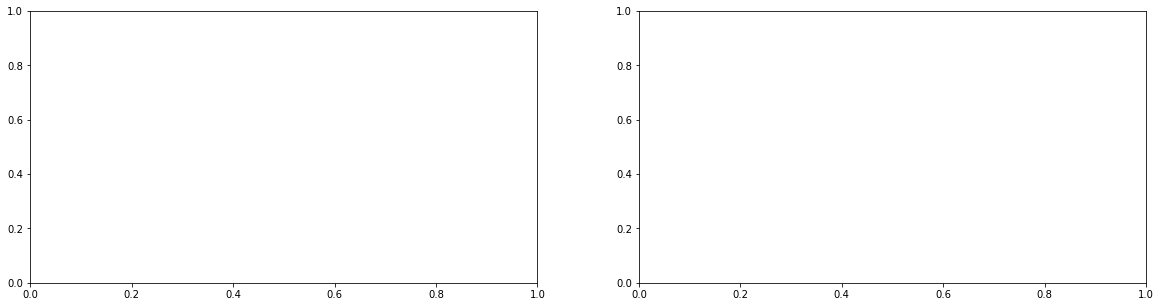

In [1]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list

def fit_powerlaw(x, y, n_bootstrap=1000, rng=None):
    """
    Fit y = a * x^alpha on log-log scale.
    Returns alpha with two error estimates:
      - se_cov:  standard error from polyfit's covariance matrix
      - se_boot: standard error from bootstrap resampling
    """
    rng = np.random.default_rng(rng)
    lx, ly = np.log(x), np.log(y)

    # ── Covariance-based SE ───────────────────────────────────────────────────
    coeffs, cov = np.polyfit(lx, ly, deg=1, cov=True)
    alpha    = coeffs[0]          # power-law exponent
    se_cov   = np.sqrt(cov[0, 0]) # SE on the slope

    # ── Bootstrap SE ─────────────────────────────────────────────────────────
    idx       = np.arange(len(x))
    boot_alphas = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(idx, size=len(idx), replace=True)
        boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]

    se_boot = boot_alphas.std(ddof=1)  # ddof=1 → unbiased sample std

    return alpha, se_cov, se_boot, boot_alphas



fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

# Errors for GPT2

In [29]:
dataset = 'wikitext'
T = 128
depth = 12

results = torch.load(f"{dataset}/learning-curves/learning-curve_{dataset}.BPE8192_T{T}_d{depth}.pt")
p_list1 = results['data']
error_list1 = results['losses']

print(f"T={T}, {len(p_list1)} points")

print(p_list1)
print([e.mean().item() for e in error_list1])

T = 512
depth = 12

results = torch.load(f"{dataset}/learning-curves/learning-curve_{dataset}.BPE8192_T{T}_d{depth}.pt")
p_list2 = results['data']
error_list2 = results['losses']

print(f"T={T}, {len(p_list2)} points")
print(p_list2)
print([e.mean().item() for e in error_list2])

T=128, 8 points
[1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728]
[4.9258713722229, 4.477031230926514, 4.070967674255371, 3.723601818084717, 3.353707790374756, 3.0418527126312256, 2.8258166313171387, 2.635796308517456]
T=512, 8 points
[1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728]
[5.1162800788879395, 4.8568549156188965, 4.268621921539307, 3.847531795501709, 3.283005714416504, 2.894050359725952, 2.6188454627990723, 2.4110658168792725]


In [31]:
# lower envelope
p_list = p_list1
error_list = error_list1
error_list[4] = error_list2[4]
error_list[5] = error_list2[5]
error_list[6] = error_list2[6]
error_list[7] = error_list2[7]

for end in range(5,9):

    print(f'\n {end} points, fit:')
    rng = np.random.default_rng(42)
    x = np.array(p_list[:end])
    y = np.array([loss.mean() for loss in error_list[:end]])
    alpha, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

    print(f"alpha       = {alpha:.4f}")
    print(f"SE (cov)    = {se_cov:.4f}   → {alpha:.4f} ± {se_cov:.4f}")
    print(f"SE (boot)   = {se_boot:.4f}  → {alpha:.4f} ± {se_boot:.4f}")

    # Bootstrap also gives you percentile CIs for free (asymmetric if needed):
    lo, hi = np.percentile(boot_dist, [2.5, 97.5])
    print(f"95% boot CI = [{lo:.4f}, {hi:.4f}]")
#     fit = np.polyfit(np.log(np.array(x_list)), np.log(np.array(y_list)), 1)
#     print(f'n={end+1}, fit:', fit)


 5 points, fit:
alpha       = -0.1437
SE (cov)    = 0.0052   → -0.1437 ± 0.0052
SE (boot)   = 0.0092  → -0.1437 ± 0.0092
95% boot CI = [-0.1552, -0.1324]

 6 points, fit:
alpha       = -0.1516
SE (cov)    = 0.0057   → -0.1516 ± 0.0057
SE (boot)   = 0.0080  → -0.1516 ± 0.0080
95% boot CI = [-0.1685, -0.1341]

 7 points, fit:


/tmp/ipykernel_372717/3422379608.py:151: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]


alpha       = -0.1537
SE (cov)    = 0.0042   → -0.1537 ± 0.0042
SE (boot)   = 0.0061  → -0.1537 ± 0.0061
95% boot CI = [-0.1673, -0.1374]

 8 points, fit:
alpha       = -0.1517
SE (cov)    = 0.0034   → -0.1517 ± 0.0034
SE (boot)   = 0.0039  → -0.1517 ± 0.0039
95% boot CI = [-0.1605, -0.1467]


# Plot Scaling laws with varying context size

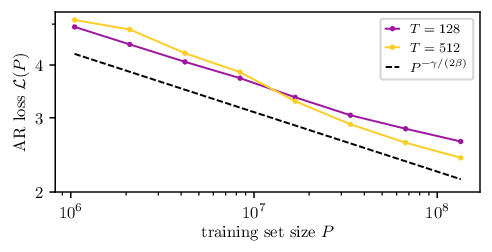

In [45]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*4.2, 1*2.2), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 4)              # [0, 1/3, 2/3, 1]
colors4 = cmap(u)                     # shape (4,4) RGBA

dataset = 'wikitext'
T = 128
depth = 12

results = torch.load(f"{dataset}/learning-curves/learning-curve_{dataset}.BPE8192_T{T}_d{depth}.pt")
p_list = results['data']
error_list = results['losses']
ax.plot([p for p in p_list], [loss.mean() for loss in error_list], color=colors4[1], marker='.', label=fr'$T={T}$')


T = 512
depth = 12

results = torch.load(f"{dataset}/learning-curves/learning-curve_{dataset}.BPE8192_T{T}_d{depth}.pt")
p_list = results['data']
error_list = results['losses']
ax.plot([p for p in p_list], [loss.mean() for loss in error_list], color=colors4[3], marker='.', label=fr'$T={T}$')

ax.plot([1048576,134217728],[30*1048576**-(.265/(2*.94)),30*134217728**-(.265/(2*.94))],'k--', label=r'$P^{-\gamma/(2\beta)}$')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'AR loss $\mathcal{L}(P)$', fontsize=10)
ax.set_xlabel(r'training set size $P$', fontsize=10)

ticks  = [2, 3, 4]
labels = ["2", "3", "4"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

fig.tight_layout()

In [46]:
fig.savefig('wikitext/'+f'L_P__wikitext.BPE8192__GPT2_APE.pdf', bbox_inches="tight")

/home/cagnetta/anaconda3/envs/llm/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/cagnetta/anaconda3/envs/llm/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


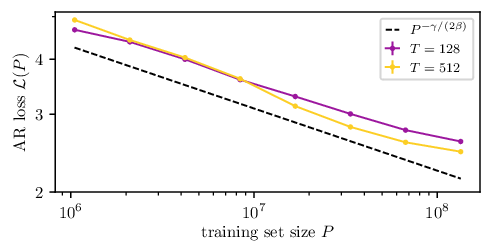

In [47]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*4.2, 1*2.2), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 4)              # [0, 1/3, 2/3, 1]
colors4 = cmap(u)                     # shape (4,4) RGBA

dataset = 'wikitext'
T = 128
depth = 12

results = torch.load(f"{dataset}/learning-curves/learning-curve_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[1], marker='.', label=fr'$T={T}$')


T = 512
depth = 12

results = torch.load(f"{dataset}/learning-curves/learning-curve_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[3], marker='.', label=fr'$T={T}$')

ax.plot([1048576,134217728],[30*1048576**-(.265/(2*.94)),30*134217728**-(.265/(2*.94))],'k--', label=r'$P^{-\gamma/(2\beta)}$')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'AR loss $\mathcal{L}(P)$', fontsize=10)
ax.set_xlabel(r'training set size $P$', fontsize=10)

ticks  = [2, 3, 4]
labels = ["2", "3", "4"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


fig.tight_layout()

In [48]:
fig.savefig('wikitext/'+f'L_P__wikitext.BPE8192__GPT2_RoPE.pdf', bbox_inches="tight")

# $n$-grams collapse

### GPT2, $T=128$

8 torch.Size([1, 128])


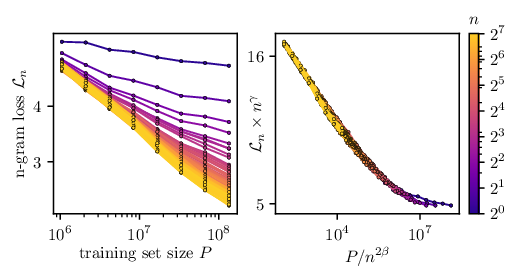

In [50]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

dataset = 'wikitext'
T = 128
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [51]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_APE_T128.pdf', bbox_inches="tight")

8 torch.Size([1, 128])


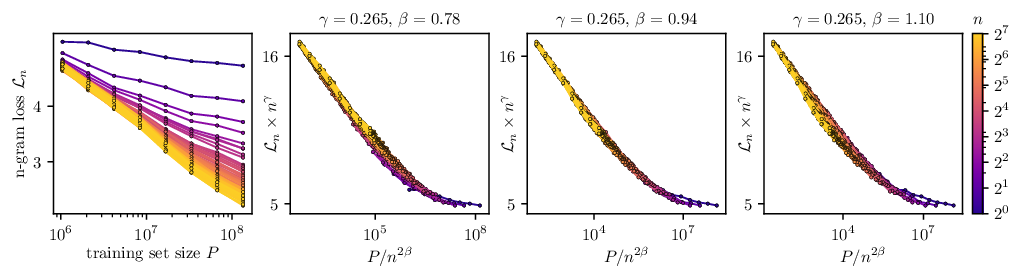

In [53]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 128
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.78)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*1.1)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.265$, $\beta=0.78$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.265$, $\beta=1.10$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [54]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_APE_T128__error_beta.pdf', bbox_inches="tight")

8 torch.Size([1, 128])


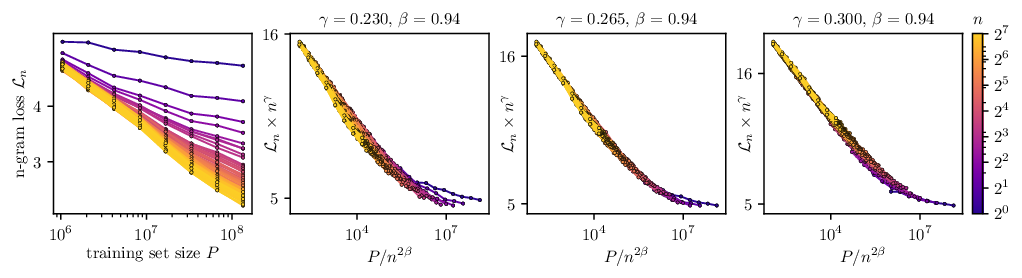

In [55]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 128
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.23 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.30 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.230$, $\beta=0.94$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.300$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [56]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_APE_T128__error_gamma.pdf', bbox_inches="tight")

### GPT2, $T=512$

8 torch.Size([1, 512])


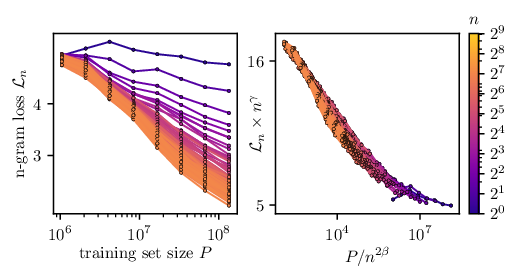

In [57]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

dataset = 'wikitext'
T = 512
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [58]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_APE_T{T}.pdf', bbox_inches="tight")

8 torch.Size([1, 512])


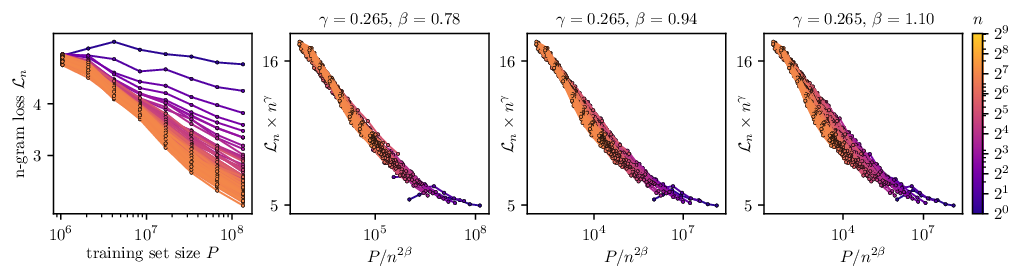

In [59]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 512
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.78)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*1.1)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.265$, $\beta=0.78$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.265$, $\beta=1.10$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [60]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_APE_T{T}__error_beta.pdf', bbox_inches="tight")

8 torch.Size([1, 512])


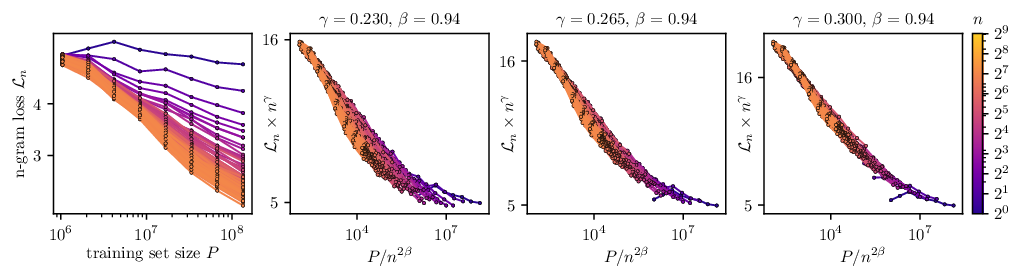

In [61]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 512
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.23 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.30 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.230$, $\beta=0.94$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.300$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [62]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_APE_T{T}__error_gamma.pdf', bbox_inches="tight")

### GPT2+RoPE, $T=128$

8 torch.Size([1, 128])


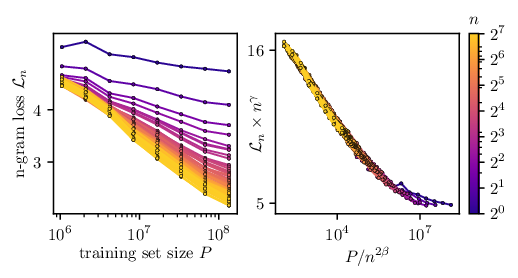

In [75]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

dataset = 'wikitext'
T = 128
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [76]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_RoPE_T{T}.pdf', bbox_inches="tight")

8 torch.Size([1, 128])


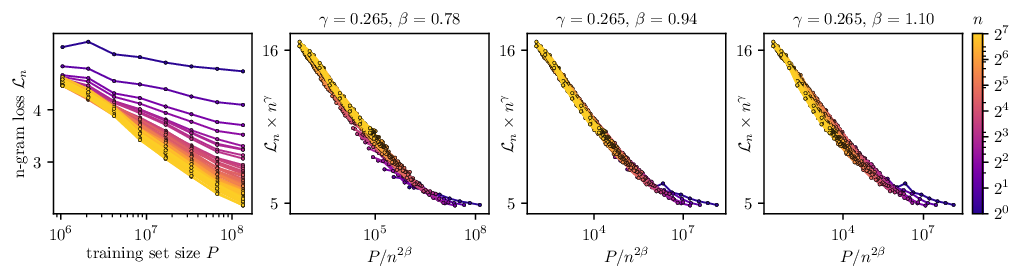

In [77]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 128
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.78)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*1.1)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.265$, $\beta=0.78$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.265$, $\beta=1.10$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [78]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_RoPE_T{T}__error_beta.pdf', bbox_inches="tight")

8 torch.Size([1, 128])


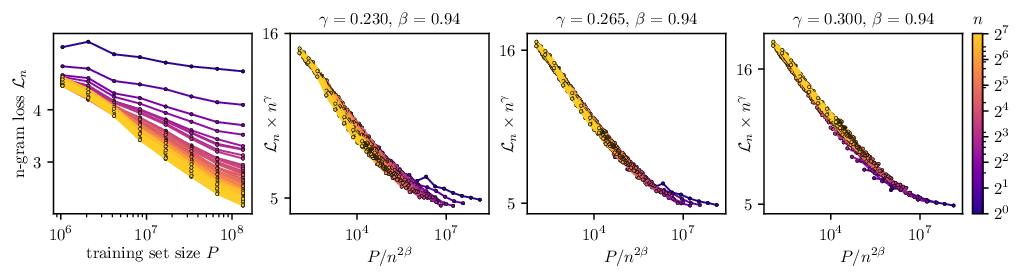

In [79]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 128
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.23 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.30 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.230$, $\beta=0.94$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.300$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [80]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_RoPE_T{T}__error_gamma.pdf', bbox_inches="tight")

### GPT2+RoPE, $T=512$

8 torch.Size([1, 512])


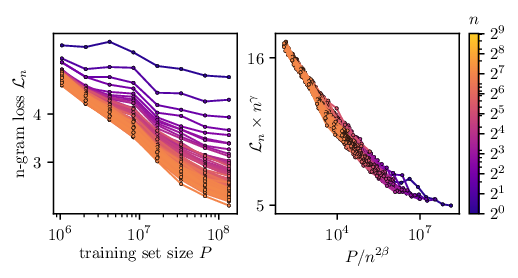

In [81]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

dataset = 'wikitext'
T = 512
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [82]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_RoPE_T{T}.pdf', bbox_inches="tight")

8 torch.Size([1, 512])


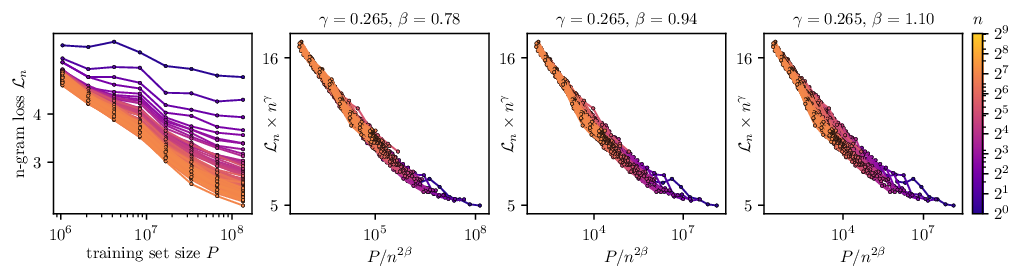

In [83]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 512
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.78)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*1.1)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.265$, $\beta=0.78$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.265$, $\beta=1.10$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [84]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_RoPE_T{T}__error_beta.pdf', bbox_inches="tight")

8 torch.Size([1, 512])


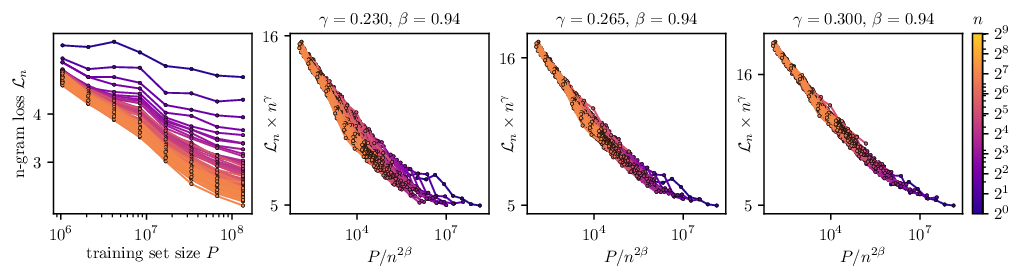

In [85]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

dataset = 'wikitext'
T = 512
depth = 12

gamma = 0.265
beta = 0.94

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.23 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.30 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.230$, $\beta=0.94$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.265$, $\beta=0.94$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.300$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 3, 4]
labels = [ "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [5, 16]
labels = [ "5", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [86]:
fig.savefig('wikitext/'+f'L_n_P_collapse__wikitext.BPE8192__GPT2_RoPE_T{T}__error_gamma.pdf', bbox_inches="tight")